In [10]:
import pandas as pd

data = pd.read_csv("StudyHrs_Score_corrected.csv", encoding='utf-8')

In [11]:
data

,Study_Hours,Scores,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1.00,32.48,NaN,NaN,NaN
1,1.18,31.15,NaN,NaN,NaN
2,1.37,36.91,NaN,NaN,NaN
3,1.55,43.13,NaN,NaN,NaN
4,1.73,36.18,NaN,NaN,NaN
5,1.92,38.01,NaN,NaN,NaN
6,2.10,48.92,NaN,NaN,NaN
7,2.29,46.69,NaN,NaN,NaN
8,2.47,42.35,NaN,NaN,NaN
9,2.65,49.24,NaN,NaN,NaN


In [12]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

In [15]:
X, y = data.iloc[:,0], data.iloc[:,1] 

In [16]:
X

0      1.00
1      1.18
2      1.37
3      1.55
4      1.73
5      1.92
6      2.10
7      2.29
8      2.47
9      2.65
10     2.84
11     3.02
12     3.20
13     3.39
14     3.57
15     3.76
16     3.94
17     4.12
18     4.31
19     4.49
20     4.67
21     4.86
22     5.04
23     5.22
24     5.41
25     5.59
26     5.78
27     5.96
28     6.14
29     6.33
30     6.51
31     6.69
32     6.88
33     7.06
34     7.24
35     7.43
36     7.61
37     7.80
38     7.98
39     8.16
40     8.35
41     8.53
42     8.71
43     8.90
44     9.08
45     9.27
46     9.45
47     9.63
48     9.82
49    10.00
Name: Study_Hours, dtype: float64

In [36]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [37]:

lr_model.fit(pd.DataFrame(X_train), pd.DataFrame(y_train))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[9.81]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Study_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[19.87]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [38]:
lr_model.predict([[1.18]])

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[31.4383977]])

In [39]:
y_predictions = lr_model.predict(pd.DataFrame(X_test))

In [40]:
from sklearn.metrics import r2_score, mean_squared_error

print("\nRegression Coefficient:", lr_model.coef_[0])
print("Regression Intercept:", lr_model.intercept_)
print("R2 Score:", r2_score(y_test, y_predictions))
print("Mean Squared Error:", mean_squared_error(y_test, y_predictions
))


Regression Coefficient: [9.80771437]
Regression Intercept: [19.86529474]
R2 Score: 0.9657279314983219
Mean Squared Error: 20.016389669933446


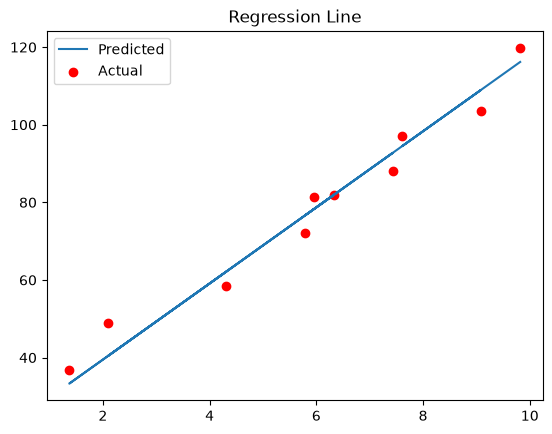

In [47]:
import matplotlib.pyplot as plt


plt.plot(X_test, y_predictions, label = "Predicted")
plt.scatter(X_test, y_test, c = "r", label = "Actual")
plt.title("Regression Line")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

r2 = 0
best = -1

for state_number in range(10000):
    np.random.seed(state_number)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=state_number)


    lr_model = LinearRegression()
    lr_model.fit(pd.DataFrame(X_train), pd.DataFrame(y_train))

    y_preds = lr_model.predict(pd.DataFrame(X_test))

    r2_curr = r2_score(pd.DataFrame(y_test), pd.DataFrame(y_preds))
    
    if r2 < r2_curr:
        r2 = r2_curr
        best = state_number
        print(f"GOT better : {r2_curr} || state : {state_number}")

print(f"BEST R2 : {r2}  || state : {best}")

ModuleNotFoundError: No module named 'sklearn'